# 01 GBDT training

In [18]:
# 这个代码干的事情其实就是用梯度提升回归树 (GradientBoostingRegressor, GBDT) 对地理网格数据建模，并做特征重要性分析 + 偏依赖图 (PDP) 提取。
import geopandas as gpd
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedKFold
from scipy.stats import randint, uniform, loguniform

# 文件夹路径
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'

def run_gbdt(grid_folder, years=[2016], n=0, unit=240):
    for year in years:
        target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
        explanatory_vars = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
        # 保存结果
        all_results = []
        pdp_records = []
        r2_comparison = []

        param_dist = {
            'n_estimators': [4168], #4168
            'learning_rate': loguniform(0.002, 0.355), #(0.002, 0.355)
            'subsample': uniform(0.545, 0.413), # [0.545,0.958]
            'max_depth' : randint(5, 14), # [5, 13]
            'min_samples_split':[2], #2
            'max_features': uniform(0.335, 0.581), #[0.335,0.916]
            }

        # === 主循环 ===
        for filename in os.listdir(grid_folder):
            if filename.endswith(f'city{year}_lst_ratio_grid_{unit}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
                
                input_path = os.path.join(grid_folder, filename)
                match = re.search(r'(\d{3,5})m', filename)
                grid_size = match.group(1)

                gdf = gpd.read_file(input_path)
                gdf_clean = gdf.replace([np.inf, -np.inf], np.nan).dropna(subset=target_vars + explanatory_vars)
                print(gdf)
                for target in target_vars:
                    X = gdf_clean[explanatory_vars]
                    y = gdf_clean[target]

                    #####################################################################
                    # 用20个 random seeds
                    np.random.seed(0)  # 固定种子以便复现
                    random_seeds = np.random.choice(10000, size=20, replace=False)
                    n = n
                    #####################################################################
                    for r in [random_seeds[n]]:

                        # 数据划分
                        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=r) # 切20次

                        gbdt = GradientBoostingRegressor(random_state=0)
                        
                        cv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=0)

                        search = RandomizedSearchCV(
                            estimator=gbdt,
                            param_distributions=param_dist,
                            n_iter= 200,
                            scoring='r2',
                            cv=cv, # cross validation
                            verbose=3,
                            n_jobs=-1,
                            random_state=0
                        )

                        search.fit(X_train, y_train)
                        folder = os.path.join(grid_folder, r'Machine Learning')
                        os.makedirs(folder, exist_ok=True)

                        # 先保存一份 checkpoint (CSV，追加方式)
                        checkpoint_path = os.path.join(folder, f"{year}_{target}_seed{n}_checkpoint_{unit}m.csv")
                        df_cv = pd.DataFrame(search.cv_results_)
                        if not os.path.exists(checkpoint_path):
                            df_cv.to_csv(checkpoint_path, index=False)
                        else:
                            df_cv.to_csv(checkpoint_path, mode='a', header=False, index=False)
                        print(f"[SAVE] checkpoint -> {checkpoint_path}")

                        # 再保存原本的 Excel（完整結果）
                        cv_path = os.path.join(folder, f"{n}_{r}_GBDT_{target}_cv_results_{unit}m.xlsx")
                        try:
                            df_cv.to_excel(cv_path, index=False)
                            print(f"[SAVE] CV results -> {cv_path}")
                        except Exception as e:
                            print(f"[ERROR] Save CV results failed: {cv_path} | {e}")
                            raise

                        # 使用测试集评估
                        best_model = search.best_estimator_
                        y_train_pred = best_model.predict(X_train)
                        y_test_pred = best_model.predict(X_test)

                        r2_train = best_model.score(X_train, y_train)
                        r2_test = r2_score(y_test, y_test_pred)

                        rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
                        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

                        print(f" {filename} | {target} 最佳参数: {search.best_params_} | R²_train={r2_train:.3f} | R²_test={r2_test:.3f}")

                        for var, importance in zip(explanatory_vars, best_model.feature_importances_):
                            all_results.append({
                                'GridSize': grid_size,
                                'Target': target,
                                'Feature': var,
                                'Random seed':r,
                                'FeatureImportance_TrainModel': round(importance, 4),
                                'Train_R2': round(r2_train, 4),
                                'Train_RMSE': round(rmse_train, 4),
                                'Test_R2': round(r2_test, 4),
                                'Test_RMSE': round(rmse_test, 4),
                                **search.best_params_
                            })
                            r2_comparison.append({
                                'GridSize': grid_size,
                                'Target': target,
                                'Random seed':r,
                                'Train_R2': round(r2_train, 4),
                                'Test_R2': round(r2_test, 4),
                                'Train_RMSE': round(rmse_train, 4),
                                'Test_RMSE': round(rmse_test, 4)
                            })
                

                
                #   保存模型训练后的结果
                df_all = pd.DataFrame(all_results)

                df_all.to_excel(os.path.join(folder, f'{year} GBDT_Random_Search_Results_{n}_{r}_{unit}m.xlsx'), index=False)
                df_r2 = pd.DataFrame(r2_comparison)
                df_r2 = df_r2.sort_values(['Target', 'GridSize'])
                df_r2.to_excel(os.path.join(folder, f'{year} R2_Comparison_Train_vs_Test_{n}_{r}_{unit}m.xlsx'), index=False)
                # print("✅ R² train vs test comparison saved.")

run_gbdt(grid_folder, years=[2016], n=3,unit=240)

                                   UFID        BJCD   NAME    DIVI      SCLS  \
0     100037608080G00110100000000000008  1100000000  ?????  HJD002  G0018112   
1     100037608080G00110100000000000008  1100000000  ?????  HJD002  G0018112   
2     100037608080G00110100000000000008  1100000000  ?????  HJD002  G0018112   
3     100037608080G00110100000000000008  1100000000  ?????  HJD002  G0018112   
4     100037608080G00110100000000000008  1100000000  ?????  HJD002  G0018112   
...                                 ...         ...    ...     ...       ...   
7313  100037608080G00110100000000000008  1100000000  ?????  HJD002  G0018112   
7314  100037608080G00110100000000000008  1100000000  ?????  HJD002  G0018112   
7315  100037608080G00110100000000000008  1100000000  ?????  HJD002  G0018112   
7316  100037608080G00110100000000000008  1100000000  ?????  HJD002  G0018112   
7317  100037608080G00110100000000000008  1100000000  ?????  HJD002  G0018112   

          FMTA  Shape_Area  city_id    

c:\Users\owner\Python\Python311\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


[SAVE] checkpoint -> D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\2016_nor_2016_seed3_checkpoint_240m.csv
[SAVE] CV results -> D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\3_5906_GBDT_nor_2016_cv_results_240m.xlsx
 city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp | nor_2016 最佳参数: {'learning_rate': 0.009826069993112911, 'max_depth': 7, 'max_features': 0.38456564633196666, 'min_samples_split': 2, 'n_estimators': 4168, 'subsample': 0.636436732318915} | R²_train=0.998 | R²_test=0.934
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[SAVE] checkpoint -> D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\2016_ext_2016_seed3_checkpoint_240m.csv
[SAVE] CV results -> D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\3_5906_GBDT_ext_2016_cv_results_240m.xlsx
 city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp | ext_2016 最佳参数: {'learning_rate': 0.02201641

# 02 SDM result

In [19]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import libpysal
from spreg import ML_Error, ML_Lag
from libpysal.weights import lag_spatial

# -----------------------------
# 设置路径
# -----------------------------
grid_folder = r"D:\seoul\grids\lst_map\final_clean\480_based"
output_folder = os.path.join(grid_folder, 'statistics')
os.makedirs(output_folder, exist_ok=True)

# -----------------------------
# 准备变量
# -----------------------------
results_list = []
def show_formula(model, model_type='SDM'):
    # 处理 y 名称
    y_name = model.name_y if isinstance(model.name_y, str) else model.name_y[0]

    coefs = model.betas.flatten()
    vars_ = model.name_x

    terms = []
    for coef, var in zip(coefs, vars_):
        if var.lower() in ['const', 'constant']:  # 常数项
            terms.append(f"{coef:.4f}")
        else:
            terms.append(f"{coef:.4f}*{var}")

    formula = f"{y_name} = "

    # SDM rho 处理
    if model_type == 'SDM' and hasattr(model, 'rho'):
        rho_term = f"{model.rho:.4f}*W{y_name}"
        formula += " + ".join(terms[:1] + terms[1:])  # 常数项 0 + Wy + X + WX
        return formula

    # SDEM lambda 处理
    if model_type == 'SDEM' and hasattr(model, 'lambda_'):
        terms.append(f"{model.lambda_:.4f}*error")

    formula += " + ".join(terms)
    return formula


param_list = []
unit = 240

for year in [2016]:
    target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
    explanatory_vars =       ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
    explanatory_vars_clean = ['BCR', 'BHV',  'SVF', 'NDVI', 'EV', 'WR']

    for filename in os.listdir(grid_folder):
        if filename.endswith(f'city{year}_lst_ratio_grid_{unit}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
            path = os.path.join(grid_folder, filename)
            gdf = gpd.read_file(path)
            gdf = gdf.replace([np.inf, -np.inf], np.nan)

            for target in target_vars:
                if target not in gdf.columns:
                    continue

                # 只保留完整数据
                data = gdf[explanatory_vars + [target]].dropna()
                if data.empty:
                    continue

                data_gdf = gdf.loc[data.index]
                print(f"CRS: {data_gdf.crs}, File: {filename}, Target: {target}")

                # -----------------------------
                # 空间权重矩阵
                # -----------------------------
                threshold = 1000
                w = libpysal.weights.DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                print("Min neighbor count:", min(w.cardinalities.values()))
                w_name = 'W1000'
                ds_name = f'yr{year}'

                # -----------------------------
                # y 与 X
                # -----------------------------
                yi = data[target].values.reshape(-1, 1)
                x = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
                name_x = explanatory_vars 
                # print(len(name_x), X_all.shape[1])
                
                n, k = x.shape  # 原始自变量数量

                # -----------------------------
                # 模型估计
                # -----------------------------
                models = {}
                slx_vars_bool = [v in explanatory_vars_clean for v in explanatory_vars]
                # SDM
                models['SDM'] = ML_Lag(
                    yi, x, w=w,
                    name_y=target, name_x=name_x, slx_lags=1, slx_vars=slx_vars_bool, # type: ignore
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True, spat_impacts=['full']
                )

                # SDEM
                models['SDEM'] = ML_Error(
                    yi, x, w=w,
                    name_y=target, name_x=name_x, slx_lags=1, slx_vars=slx_vars_bool, # type: ignore
                    name_w=w_name, name_ds=ds_name,
                    spat_diag=True
                )

                for model_name, model in models.items():
                    formula_sdm = show_formula(models['SDM'], model_type='SDM')
                   
                    formula_sdem = show_formula(models['SDEM'], model_type='SDEM')

                    # 系数转成 dict，列名是变量名
                    coef_sdm = dict(zip(models['SDM'].name_x, models['SDM'].betas.flatten()))
                    coef_sdem = dict(zip(models['SDEM'].name_x, models['SDEM'].betas.flatten()))

                    #  lambda_ 加进去, rho 不用加是因为已经有Wy了
                    if hasattr(models['SDEM'], 'lambda_'):
                        coef_sdem['lambda'] = models['SDEM'].lambda_


                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDM",
                    "Formula": formula_sdm,
                    **coef_sdm
                })

                param_list.append({
                    "Year": year,
                    "Grid": filename.split("_")[4],
                    "Target": target,
                    "Model": "SDEM",
                    "Formula": formula_sdem,
                    **coef_sdem
                })
                print(formula_sdm)


# -----------------------------
# 汇总输出
# -----------------------------
all_params_df = pd.DataFrame(param_list)
param_output = os.path.join(output_folder, f"SDM_SDEM_all_params_{unit}m.xlsx")
all_params_df.to_excel(param_output, index=False)

CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korea_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], File: city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp, Target: nor_2016


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


Min neighbor count: 5


c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


nor_2016 = 1.4955 + 0.0251*BCR + -0.0023*BHV + 6.8624*SVF + -17.0752*NDVI + -0.0140*EV + -0.1006*WR + -0.0082*Dist_W + -0.0260*Dist_P + -0.0058*Dist_M + -0.0337*W_BCR + -0.0006*W_BHV + -5.6165*W_SVF + 12.7333*W_NDVI + 0.0147*W_EV + 0.0833*W_WR + 0.9470*W_nor_2016
CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korea_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], File: city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp, Target: ext_2016


...

ext_2016 = 2.2234 + 0.0385*BCR + -0.0069*BHV + 6.9385*SVF + -32.9625*NDVI + -0.0184*EV + -0.1681*WR + -0.0294*Dist_W + -0.0266*Dist_P + -0.0156*Dist_M + -0.0492*W_BCR + 0.0019*W_BHV + -5.9495*W_SVF + 27.6248*W_NDVI + 0.0191*W_EV + 0.1448*W_WR + 0.9548*W_ext_2016
CRS: PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korea_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]], File: city2016_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp, Target: hr_2016


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


Min neighbor count: 5


c:\Users\owner\Python\Python311\Lib\site-packages\spreg\ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


hr_2016 = -0.6432 + -0.0134*BCR + 0.0048*BHV + -0.0615*SVF + 15.9016*NDVI + 0.0043*EV + 0.0669*WR + 0.0174*Dist_W + -0.0013*Dist_P + 0.0070*Dist_M + 0.0166*W_BCR + -0.0022*W_BHV + 0.2491*W_SVF + -14.9175*W_NDVI + -0.0045*W_EV + -0.0613*W_WR + 0.9802*W_hr_2016


In [17]:

# -----------------------------
# 准备变量
# -----------------------------
year = 2016
unit = 240
target_vars = [f'nor_{year}', f'ext_{year}', f'hr_{year}']
explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

for filename in os.listdir(grid_folder):
    if filename.endswith(f'city{year}_lst_ratio_grid_{unit}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
        path = os.path.join(grid_folder, filename)
        gdf = gpd.read_file(path)
        gdf = gdf.replace([np.inf, -np.inf], np.nan)
        # 找重复行（最重要）
        dup = gdf.geometry.centroid.duplicated()
        print("重复centroid数量:", dup.sum())

        # 检查 CRS
        print(gdf.crs)

        # 检查 polygon 是否有效
        print(gdf.geometry.is_valid.sum(), "/", len(gdf))

        # 检查最小距离
        from shapely.ops import nearest_points

        cent = gdf.geometry.centroid
        dist_min = []
        for i in range(len(cent)):
            for j in range(i+1, len(cent)):
                dist_min.append(cent[i].distance(cent[j]))

        print("最小距离:", min(dist_min))

重复centroid数量: 0
PROJCS["KGD2002_Central_Belt",GEOGCS["GCS_KGD2002",DATUM["D_Korea_Geodetic_Datum_2002",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",38],PARAMETER["central_meridian",127],PARAMETER["scale_factor",1],PARAMETER["false_easting",200000],PARAMETER["false_northing",500000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
7318 / 7318
最小距离: 240.0852407408339


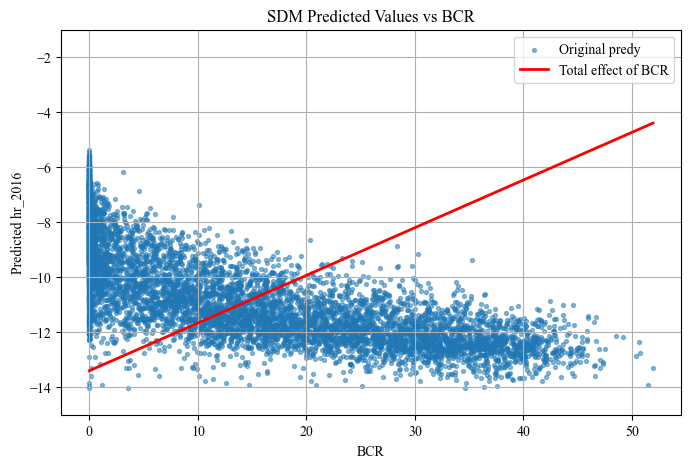

KeyboardInterrupt: 

In [11]:
effects_file = r"D:\seoul\grids\lst_map\final_clean\480_based\statistics\SDM_SDEM_all_params_240m.xlsx"
df_effects = pd.read_excel(effects_file)

df_effects = df_effects[df_effects['Model'] == 'SDM'].reset_index(drop=True)
df_effects = df_effects[df_effects['Target'] == 'hr_2016'].reset_index(drop=True)
row = df_effects.loc[0]

explanatory_vars = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']
beta = np.array([row[v] for v in explanatory_vars])
theta = np.array([row[f"W_{v}"] for v in explanatory_vars_clean])
constant = np.ones(len(data)) * row['CONSTANT']

X_main = data[explanatory_vars].values
WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)
W_dense = np.array(w.full()[0])
I = np.eye(len(data))

y_final = np.linalg.inv(I - rho * W_dense) @ (
    constant + X_main @ beta + WX_clean @ theta
)

import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import lag_spatial

for feature in explanatory_vars:
    other_features = [f for f in explanatory_vars if f != feature]

    # 用原数据均值固定其他变量
    X_matrix = data[explanatory_vars].copy().values  # 原始数据行数
    predy_list = []

    feature_min = data[feature].min()
    feature_max = data[feature].max()
    n_points = 100
    feature_range = np.linspace(feature_min, feature_max, n_points)

    for val in feature_range:
        X_matrix_temp = X_matrix.copy()
        X_matrix_temp[:, explanatory_vars.index(feature)] = val  # 修改 BCR
        # WX_clean
        WX_clean = lag_spatial(w, X_matrix_temp[:, :len(explanatory_vars_clean)])
        # I - rho*W
        I = np.eye(len(X_matrix_temp))
        W_dense = np.array(w.full()[0])
        y_temp = np.linalg.inv(I - rho * W_dense) @ (constant + X_matrix_temp @ beta + WX_clean @ theta)
        predy_list.append(y_temp.mean())  # 取平均作为单变量效果

    plt.figure(figsize=(8,5))

    plt.scatter(data[feature], models['SDM'].predy.flatten(), s=8, alpha=0.5, label='Original predy')
    plt.plot(feature_range, predy_list, color='red', linewidth=2, label=f'Total effect of {feature}')

    plt.xlabel(feature)
    plt.ylabel(f"Predicted {target}")
    plt.title(f"SDM Predicted Values vs {feature}")
    plt.grid(True)
    plt.ylim(-15,-1)
    plt.legend()
    plt.show()

In [15]:
print("\n=== 列名检查 ===")
data = gdf[explanatory_vars + [target]].dropna()
print(data.columns)


=== 列名检查 ===
Index(['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M',
       'hr_2016'],
      dtype='object')


  Variable   Direct  Indirect    Total
0      BCR  -0.0165    0.1777   0.1613
1      BHV   0.0059    0.1272   0.1332
2      SVF  -0.0754    9.5451   9.4697
3     NDVI  19.4855   30.1979  49.6834
4       EV   0.0053   -0.0108  -0.0055
5       WR   0.0820    0.2024   0.2843
6   Dist_W   0.0213    0.8580   0.8794
7   Dist_P  -0.0016   -0.0638  -0.0654
8   Dist_M   0.0086    0.3466   0.3553


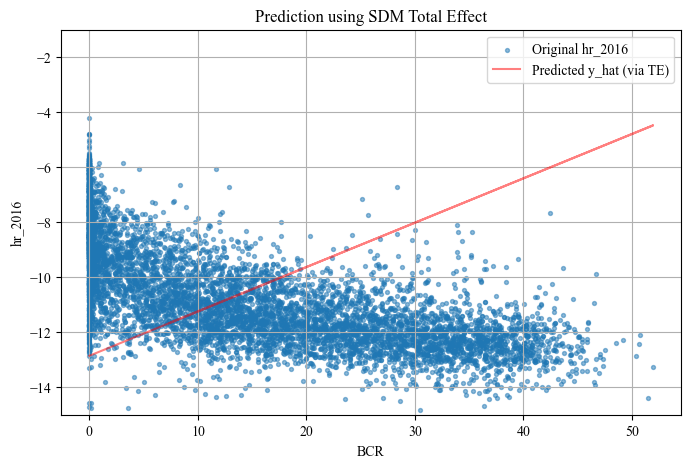

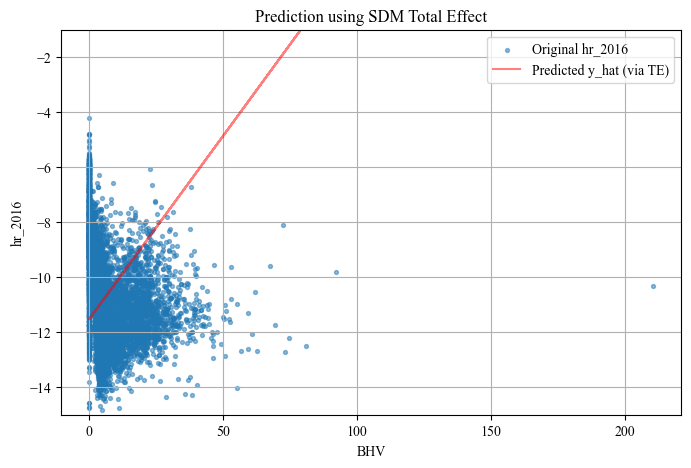

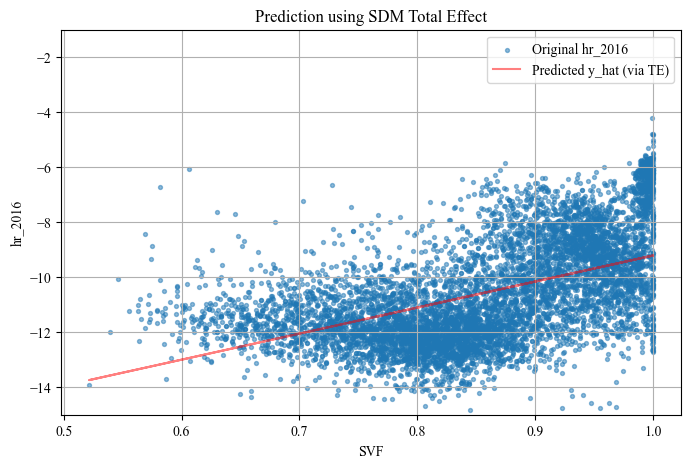

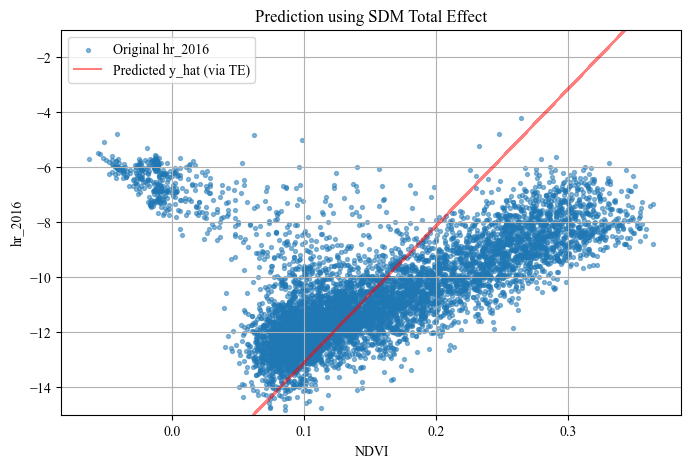

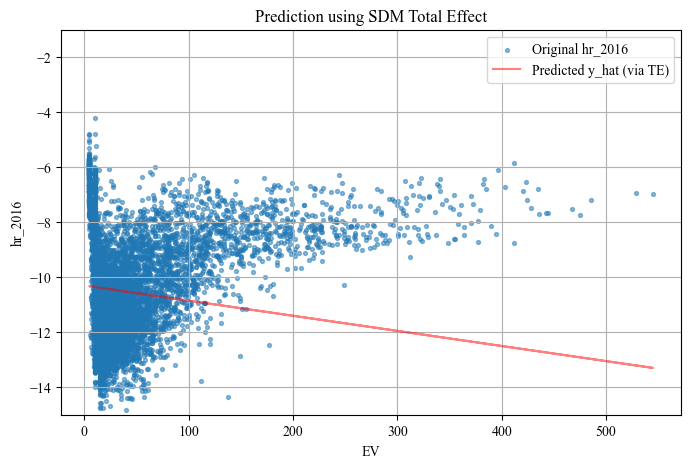

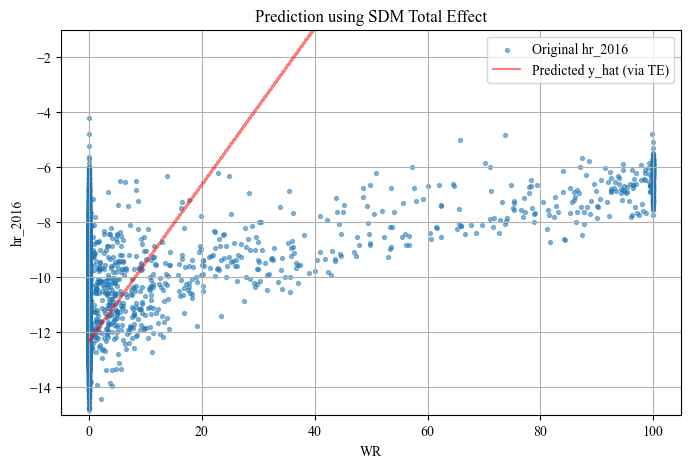

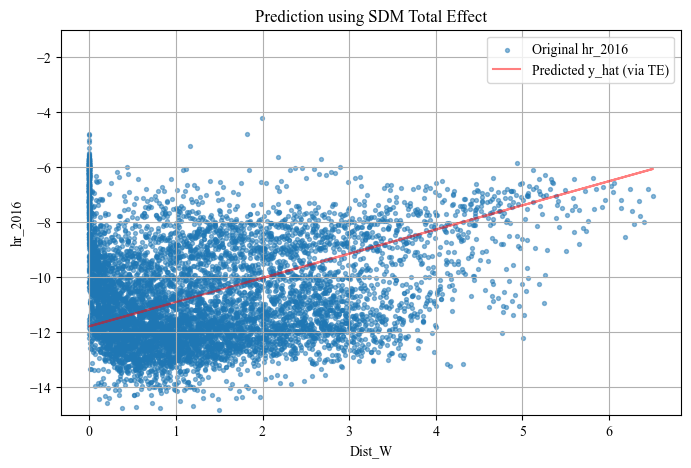

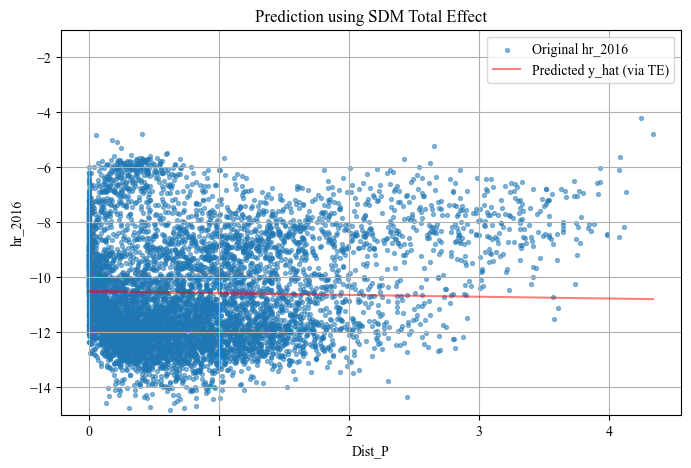

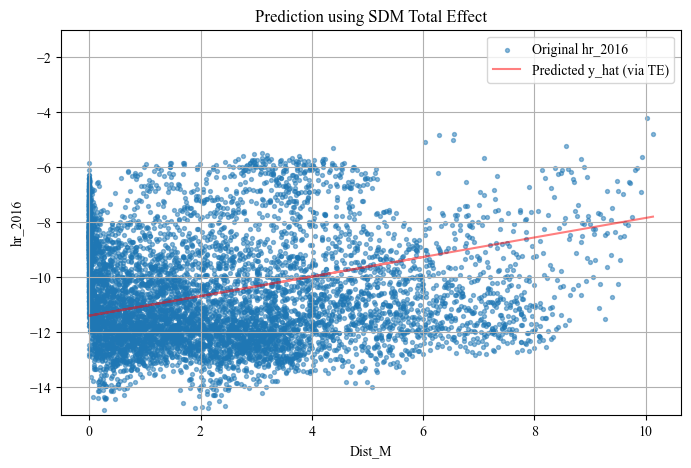

In [13]:

summary_str = str(models['SDM'].summary)
lines = summary_str.split("\n")
impacts_data = []
capture = False
for line in lines:
    if "SPATIAL DURBIN MODEL IMPACTS" in line:
        capture = True
        continue
    if capture:
        if not line.strip(): 
            break
        if "Direct" in line and "Indirect" in line and "Total" in line:
            continue
        if set(line.strip()) == {"-"}:
            continue
        parts = re.split(r"\s+", line.strip())
        if len(parts) == 4:
            var, direct, indirect, total = parts
            impacts_data.append([var, float(direct), float(indirect), float(total)])

df_impacts = pd.DataFrame(impacts_data, columns=["Variable","Direct","Indirect","Total"])
print(df_impacts)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_effects = df_impacts
for feature in explanatory_vars:
    TE_total = df_effects.loc[df_effects['Variable'] == feature, 'Total'].values[0]

    # -----------------------------
    # y_hat_i ≈ y_mean + TE_total * (BCR_i - BCR_mean)
    # -----------------------------
    y_base_mean = data['hr_2016'].mean()       # 或者使用模型原始 y_base.mean()
    bcr_mean = data[feature].mean()
    bcr_values = data[feature].values

    yhat = y_base_mean + TE_total * (bcr_values - bcr_mean)

    plt.figure(figsize=(8,5))
    plt.scatter(bcr_values, data['hr_2016'], s=8, alpha=0.5, label='Original hr_2016')
    plt.plot(bcr_values, yhat,color='red',  alpha=0.5, label='Predicted y_hat (via TE)')
    plt.xlabel(feature)
    plt.ylabel('hr_2016')
    plt.title('Prediction using SDM Total Effect')
    plt.legend()
    plt.ylim(-15,-1)
    plt.grid(True)
    plt.show()


# feature importance 

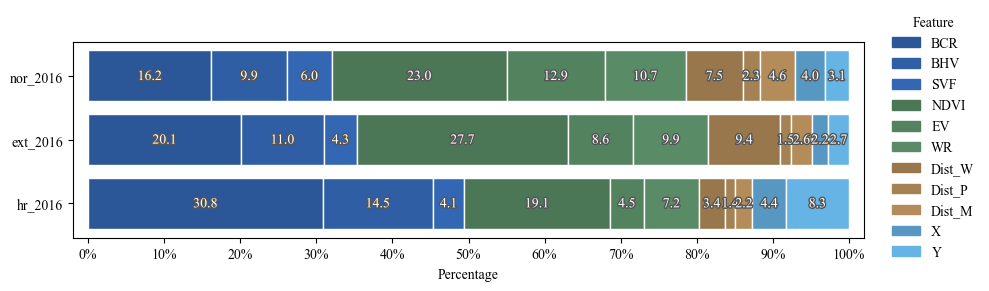

Saved to: D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\2016 final_GBDT_feature_importance_stacked_240m.png


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import hsv_to_rgb
year =2016
unit =240
# 设置全局字体为 Times New Roman
plt.rcParams["font.family"] = "Times New Roman"

# 读数据
path = rf"D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\{year} GBDT_Random_Search_Results_3_5906_{unit}m.xlsx"
df = pd.read_excel(path)

# pivot：每行一个 Target，每列一个 Feature
pivot = df.pivot_table(index='Target', columns='Feature', 
                       values='FeatureImportance_TrainModel', aggfunc='sum').fillna(0)

# 归一化（每个 target 的行和为 1）
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

# 手动调整 Target 的行顺序
row_order = ['hr_2016', 'ext_2016','nor_2016']
pivot_norm = pivot_norm.reindex(row_order)

# 指定 Feature 顺序
explanatory_vars_gbdt = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 
                         'Dist_W', 'Dist_P', 'Dist_M', 'X', 'Y']


# 四组特征
groups = {
    'group1': ['BCR', 'BHV', 'SVF'],          # 湖蓝系
    'group2': ['NDVI', 'EV', 'WR'],           # 藏蓝系
    'group3': ['Dist_W', 'Dist_P', 'Dist_M'], # 棕色系
    'group4': ['X', 'Y']                      # 墨绿色系
}

base_colors = {
    'group4': np.array([0.4, 0.7, 0.9]),   # 柔和湖蓝
    'group1': np.array([0.2, 0.4, 0.7]),   # 深藏蓝
    'group2': np.array([0.35, 0.55, 0.4]), # 墨绿色
    'group3': np.array([0.7, 0.55, 0.35])# 高级咖啡棕}
 } 
# 生成组内渐变色（浅→深）
def generate_gradient_colors(features, base_rgb):
    n = len(features)
    colors = []
    for i in range(n):
        factor = 0.85 + 0.15*(i/(n-1))  # 浅→深
        colors.append(base_rgb * factor)
    return dict(zip(features, colors))

color_map = {}
for gname, feats in groups.items():
    color_map.update(generate_gradient_colors(feats, base_colors[gname]))

# 绘图
fig, ax = plt.subplots(figsize=(10, max(3, 0.8 * len(pivot_norm))))
bottom = np.zeros(len(pivot_norm))
# 绘图前设置 X 轴范围和刻度
ax.set_xlim(-0.02, 1.02)  # 超过 1 点点空间

# 设置 X 轴刻度为百分比
ax.set_xticks(np.linspace(0, 1, 11))  # 0,0.1,...,1
ax.set_xticklabels([f"{int(x*100)}%" for x in np.linspace(0, 1, 11)])

for feature in explanatory_vars_gbdt:
    vals = pivot_norm[feature].values
    ax.barh(pivot_norm.index, vals, left=bottom, color=color_map[feature], edgecolor='white')
    for i, val in enumerate(vals):
        txt = ax.text(
            bottom[i] + val/2, i, f"{val*100:.1f}", 
            va='center', ha='center', fontsize=10, color="white"
        )
        # 给文字加描边
        txt.set_path_effects([
            path_effects.Stroke(linewidth=2, foreground='#555555'),  # 描边颜色
            path_effects.Normal()  # 正常文字显示
        ])
    bottom += vals

# legend
handles = [plt.Rectangle((0,0),1,1,color=color_map[feature]) for feature in explanatory_vars_gbdt]
ax.legend(handles, explanatory_vars_gbdt, bbox_to_anchor=(1.02, 1.2), loc='upper left', title='Feature', frameon=False)

ax.set_xlabel("Percentage")
# ax.set_ylabel("Target")
# ax.set_title("Feature importance proportions per Target")

plt.tight_layout()
# 保存到本地（示例）
out_file = fr"D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\{year} final_GBDT_feature_importance_stacked_{unit}m.png"
fig.savefig(out_file, dpi=200, bbox_inches='tight')
plt.tight_layout()
plt.show()
print("Saved to:", out_file)

## pdp hr 出图

In [21]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
years = [2016]
unit = 240
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = fr'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self\{unit}'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt =  ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars =       ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']


for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_{unit}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\{year} GBDT_Random_Search_Results_3_5906_{unit}m.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdm = rf'{grid_folder}\statistics\SDM_SDEM_all_params_{unit}m.xlsx'
    best_df_sdm = pd.read_excel(best_params_file_sdm)
    best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            plt.rcParams["font.family"] = "Times New Roman"
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns) # type: ignore
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDM
                row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]
                rho_col = [c for c in row_sdm.index if c.lower() == f"w_{target.lower()}"] #rho_col = ['W_hr_2016']
                rho = float(row_sdm[rho_col[0]]) 

                params_sdm = {
                    'CONSTANT': row_sdm['CONSTANT'],
                    'Wy': rho,
                    'BCR': row_sdm['BCR'],
                    'BHV': row_sdm['BHV'],
                    'SVF': row_sdm['SVF'],
                    'NDVI': row_sdm['NDVI'],
                    'EV': row_sdm['EV'],
                    'WR': row_sdm['WR'],
                    'Dist_W': row_sdm['Dist_W'],
                    'Dist_P': row_sdm['Dist_P'],
                    'Dist_M': row_sdm['Dist_M'],
                    'W_BCR': row_sdm['W_BCR'],
                    'W_BHV': row_sdm['W_BHV'],
                    'W_SVF': row_sdm['W_SVF'],
                    'W_NDVI': row_sdm['W_NDVI'],
                    'W_EV': row_sdm['W_EV'],
                    'W_WR': row_sdm['W_WR']
                }

                # SDM 预测
                data = gdf_clean[explanatory_vars + [target]].dropna()
                data_gdf = gdf_clean.loc[data.index].reset_index(drop=True)

                threshold = 1000
                w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                W = np.array(w.full()[0])

                constant = np.array([params_sdm.get('CONSTANT', 0)]) 
                beta = np.array([params_sdm.get(var, 0) for var in explanatory_vars])   # (9,)
                theta = np.array([params_sdm.get(f"W_{var}", 0) for var in explanatory_vars_clean])  # (6,)
                rho = params_sdm.get("Wy", 0)

                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

                # SDM 计算
                I = np.eye(len(X_main))
                A_inv = np.linalg.inv(I - rho * W)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                beta_all = np.array([row_sdm[var] for var in ['CONSTANT'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]], dtype=float)
                clean_col_indices = [explanatory_vars.index(c) for c in explanatory_vars_clean]  # len=6
                y_sdm_pred_list = []

                for val in X_grid:
                    X_temp = X_main.copy()
                    feature_idx = explanatory_vars.index(feature)
                    X_temp[:, feature_idx] = val

                    WX_temp = WX_clean.copy()
                    if feature in explanatory_vars_clean:
                        m = clean_col_indices.index(explanatory_vars.index(feature))
                        WX_temp[:, m] = lag_spatial(w, X_temp[:, feature_idx].reshape(-1, 1)).flatten()

                    X_all_temp = np.hstack([np.ones((len(data), 1)), X_temp, WX_temp])

                    y_temp = A_inv @ (X_all_temp @ beta_all)
                    y_sdm_pred_list.append(y_temp.mean())

                # 转为 numpy 数组
                y_sdm_pred_array = np.array(y_sdm_pred_list)
                
                color_gbdt = '#333333'  # 黑色
                color_sdm = '#555555'  # 黑色虚线
                
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdm_pred_array, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())


            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison_{unit}.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison_{unit}.png")

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved BCR_hr_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved BHV_hr_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


...

✅ Saved Dist_W_hr_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved Dist_P_hr_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved Dist_M_hr_2016_comparison_240.png


# pdp ext + nor 出图

In [22]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
years = [2016]
unit = 240
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = fr'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self\{unit}'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt =  ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars =       ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_{unit}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\{year} GBDT_Random_Search_Results_3_5906_{unit}m.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdm = rf'{grid_folder}\statistics\SDM_SDEM_all_params_{unit}m.xlsx'
    best_df_sdm = pd.read_excel(best_params_file_sdm)
    best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']
    
    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()

    for target in target_folder[1:]:
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            plt.rcParams["font.family"] = "Times New Roman"
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns) # type: ignore
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDM
                row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]
                rho_col = [c for c in row_sdm.index if c.lower() == f"w_{target.lower()}"] #rho_col = ['W_hr_2016']
                rho = float(row_sdm[rho_col[0]]) 

                params_sdm = {
                    'CONSTANT': row_sdm['CONSTANT'],
                    'Wy': rho,
                    'BCR': row_sdm['BCR'],
                    'BHV': row_sdm['BHV'],
                    'SVF': row_sdm['SVF'],
                    'NDVI': row_sdm['NDVI'],
                    'EV': row_sdm['EV'],
                    'WR': row_sdm['WR'],
                    'Dist_W': row_sdm['Dist_W'],
                    'Dist_P': row_sdm['Dist_P'],
                    'Dist_M': row_sdm['Dist_M'],
                    'W_BCR': row_sdm['W_BCR'],
                    'W_BHV': row_sdm['W_BHV'],
                    'W_SVF': row_sdm['W_SVF'],
                    'W_NDVI': row_sdm['W_NDVI'],
                    'W_EV': row_sdm['W_EV'],
                    'W_WR': row_sdm['W_WR']
                }

                # SDM 预测
                data = gdf_clean[explanatory_vars + [target]].dropna()
                data_gdf = gdf_clean.loc[data.index].reset_index(drop=True)

                threshold = 1000
                w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                W = np.array(w.full()[0])

                constant = np.array([params_sdm.get('CONSTANT', 0)]) 
                beta = np.array([params_sdm.get(var, 0) for var in explanatory_vars])   # (9,)
                theta = np.array([params_sdm.get(f"W_{var}", 0) for var in explanatory_vars_clean])  # (6,)
                rho = params_sdm.get("Wy", 0)

                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

                # SDM 计算
                I = np.eye(len(X_main))
                A_inv = np.linalg.inv(I - rho * W)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                beta_all = np.array([row_sdm[var] for var in ['CONSTANT'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]], dtype=float)
                clean_col_indices = [explanatory_vars.index(c) for c in explanatory_vars_clean]  # len=6
                y_sdm_pred_list = []

                for val in X_grid:
                    X_temp = X_main.copy()
                    feature_idx = explanatory_vars.index(feature)
                    X_temp[:, feature_idx] = val

                    WX_temp = WX_clean.copy()
                    if feature in explanatory_vars_clean:
                        m = clean_col_indices.index(explanatory_vars.index(feature))
                        WX_temp[:, m] = lag_spatial(w, X_temp[:, feature_idx].reshape(-1, 1)).flatten()

                    X_all_temp = np.hstack([np.ones((len(data), 1)), X_temp, WX_temp])

                    y_temp = A_inv @ (X_all_temp @ beta_all)
                    y_sdm_pred_list.append(y_temp.mean())

                # 转为 numpy 数组
                y_sdm_pred_array = np.array(y_sdm_pred_list)
                
                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdm = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdm = '#0000ff'  # 蓝色虚线

                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdm_pred_array, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())


            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(20, 55)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison_{unit}.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison_{unit}.png")

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved BCR_ext_nor_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved BHV_ext_nor_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

...

✅ Saved Dist_W_ext_nor_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved Dist_P_ext_nor_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved Dist_M_ext_nor_2016_comparison_240.png


# pdp hr + SDEM

In [25]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
years = [2016]
unit = 240
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = rf'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self\{unit}'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt =  ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars =       ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']


for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_{unit}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\{year} GBDT_Random_Search_Results_3_5906_{unit}m.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDM_SDEM_all_params_{unit}m.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)
    best_df_sdem = best_df_sdem[best_df_sdem['Model']=='SDEM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            plt.rcParams["font.family"] = "Times New Roman"
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns) # type: ignore
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }

                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                # y_base：平均值预测
                all_vars_base = {'CONSTANT': 1.0, **X_mean, **WX_mean.to_dict()}
                y_base = sum(params_sdem[var] * all_vars_base.get(var, 0) for var in params_sdem if var != 'lambda')
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])

                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                    
                y_sdem_pred = np.array(y_sdem_pred)
                
                color_gbdt = '#333333'  # 黑色
                color_sdm = '#555555'  # 黑色虚线
                
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDEM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())


            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(-15,-1)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison_{unit}.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison_{unit}.png")

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved BCR_hr_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved BHV_hr_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


...

✅ Saved Dist_W_hr_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved Dist_P_hr_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved Dist_M_hr_2016_comparison_240.png


# pdp ext + nor SDEM

In [26]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split

years = [2016]
unit = 240
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = fr'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self\{unit}'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt =  ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars =       ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_{unit}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\{year} GBDT_Random_Search_Results_3_5906_{unit}m.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdem = rf'{grid_folder}\statistics\SDM_SDEM_all_params_{unit}m.xlsx'
    best_df_sdem = pd.read_excel(best_params_file_sdem)
    best_df_sdem = best_df_sdem[best_df_sdem['Model']=='SDEM']


    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()

    for target in target_folder[1:]:
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in explanatory_vars:
            plt.figure(figsize=(8,5))
            plt.rcParams["font.family"] = "Times New Roman"
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns) # type: ignore
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDEM
                row_sdem = best_df_sdem[best_df_sdem['Target']==target].iloc[0]
                params_sdem = {
                    'CONSTANT': row_sdem['CONSTANT'],
                    'BCR': row_sdem['BCR'],
                    'BHV': row_sdem['BHV'],
                    'SVF': row_sdem['SVF'],
                    'NDVI': row_sdem['NDVI'],
                    'EV': row_sdem['EV'],
                    'WR': row_sdem['WR'],
                    'Dist_W': row_sdem['Dist_W'],
                    'Dist_P': row_sdem['Dist_P'],
                    'Dist_M': row_sdem['Dist_M'],
                    'W_BCR': row_sdem['W_BCR'],
                    'W_BHV': row_sdem['W_BHV'],
                    'W_SVF': row_sdem['W_SVF'],
                    'W_NDVI': row_sdem['W_NDVI'],
                    'W_EV': row_sdem['W_EV'],
                    'W_WR': row_sdem['W_WR'],
                    'lambda': row_sdem['lambda']
                }

                # SDEM 预测
                X_mean = gdf_clean[explanatory_vars].mean().to_dict()
                w = DistanceBand.from_dataframe(gdf_clean, threshold=1000, binary=False)
                w.transform = 'r'
                WX = lag_spatial(w, gdf_clean[explanatory_vars_clean].values)
                WX_mean = pd.Series(WX.mean(axis=0), index=[f"W_{v}" for v in explanatory_vars_clean])
                # y_base：平均值预测
                all_vars_base = {'CONSTANT': 1.0, **X_mean, **WX_mean.to_dict()}
                y_base = sum(params_sdem[var] * all_vars_base.get(var, 0) for var in params_sdem if var != 'lambda')
                y_sdem_pred = []
                for val in X_grid:
                    X_temp = X_mean.copy()
                    X_temp[feature] = val
                    WX_temp = WX_mean.copy()
                    if feature in explanatory_vars_clean:
                        WX_temp[feature] = pd.Series(val, index=[f"W_{feature}"])

                    all_vars = {'CONSTANT': 1.0, **X_temp, **WX_temp.to_dict()}
                    y_pred = 0
                    for var, coef in params_sdem.items():
                        if var != 'lambda':
                            y_pred += coef * all_vars.get(var, 0)
                    y_sdem_pred.append(y_pred)
                    
                y_sdem_pred = np.array(y_sdem_pred)
                
                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdem = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdem = '#0000ff'  # 蓝色虚线

                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdem_pred, color=color_sdem, linestyle='--', linewidth=2, label=f'{label_name} SDEM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())


            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(20, 55)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison_{unit}.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison_{unit}.png")

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved BCR_ext_nor_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved BHV_ext_nor_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

...

✅ Saved Dist_W_ext_nor_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved Dist_P_ext_nor_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved Dist_M_ext_nor_2016_comparison_240.png


# 打个补丁

In [32]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
years = [2016]
unit = 240
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = fr'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self\{unit}'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt =  ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars =       ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']


for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_{unit}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\{year} GBDT_Random_Search_Results_3_5906_{unit}m.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdm = rf'{grid_folder}\statistics\SDM_SDEM_all_params_{unit}m.xlsx'
    best_df_sdm = pd.read_excel(best_params_file_sdm)
    best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in ['BHV']: #['WR'] 
            plt.figure(figsize=(8,5))
            plt.rcParams["font.family"] = "Times New Roman"
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns) # type: ignore
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDM
                row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]
                rho_col = [c for c in row_sdm.index if c.lower() == f"w_{target.lower()}"] #rho_col = ['W_hr_2016']
                rho = float(row_sdm[rho_col[0]]) 

                params_sdm = {
                    'CONSTANT': row_sdm['CONSTANT'],
                    'Wy': rho,
                    'BCR': row_sdm['BCR'],
                    'BHV': row_sdm['BHV'],
                    'SVF': row_sdm['SVF'],
                    'NDVI': row_sdm['NDVI'],
                    'EV': row_sdm['EV'],
                    'WR': row_sdm['WR'],
                    'Dist_W': row_sdm['Dist_W'],
                    'Dist_P': row_sdm['Dist_P'],
                    'Dist_M': row_sdm['Dist_M'],
                    'W_BCR': row_sdm['W_BCR'],
                    'W_BHV': row_sdm['W_BHV'],
                    'W_SVF': row_sdm['W_SVF'],
                    'W_NDVI': row_sdm['W_NDVI'],
                    'W_EV': row_sdm['W_EV'],
                    'W_WR': row_sdm['W_WR']
                }

                # SDM 预测
                data = gdf_clean[explanatory_vars + [target]].dropna()
                data_gdf = gdf_clean.loc[data.index].reset_index(drop=True)

                threshold = 1000
                w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                W = np.array(w.full()[0])

                constant = np.array([params_sdm.get('CONSTANT', 0)]) 
                beta = np.array([params_sdm.get(var, 0) for var in explanatory_vars])   # (9,)
                theta = np.array([params_sdm.get(f"W_{var}", 0) for var in explanatory_vars_clean])  # (6,)
                rho = params_sdm.get("Wy", 0)

                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

                # SDM 计算
                I = np.eye(len(X_main))
                A_inv = np.linalg.inv(I - rho * W)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                beta_all = np.array([row_sdm[var] for var in ['CONSTANT'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]], dtype=float)
                clean_col_indices = [explanatory_vars.index(c) for c in explanatory_vars_clean]  # len=6
                y_sdm_pred_list = []

                for val in X_grid:
                    X_temp = X_main.copy()
                    feature_idx = explanatory_vars.index(feature)
                    X_temp[:, feature_idx] = val

                    WX_temp = WX_clean.copy()
                    if feature in explanatory_vars_clean:
                        m = clean_col_indices.index(explanatory_vars.index(feature))
                        WX_temp[:, m] = lag_spatial(w, X_temp[:, feature_idx].reshape(-1, 1)).flatten()

                    X_all_temp = np.hstack([np.ones((len(data), 1)), X_temp, WX_temp])

                    y_temp = A_inv @ (X_all_temp @ beta_all)
                    y_sdm_pred_list.append(y_temp.mean())

                # 转为 numpy 数组
                y_sdm_pred_array = np.array(y_sdm_pred_list)
                
                color_gbdt = '#333333'  # 黑色
                color_sdm = '#555555'  # 黑色虚线
                
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdm_pred_array, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())


            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(-15,17)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison_{unit}.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison_{unit}.png")

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved BHV_hr_2016_comparison_240.png


In [33]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
years = [2016]
unit = 240
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = fr'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self\{unit}'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt =  ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars =       ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']


for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_{unit}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\{year} GBDT_Random_Search_Results_3_5906_{unit}m.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdm = rf'{grid_folder}\statistics\SDM_SDEM_all_params_{unit}m.xlsx'
    best_df_sdm = pd.read_excel(best_params_file_sdm)
    best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']

    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()

    for target in target_folder[2:]:
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in ['NDVI']: 
            plt.figure(figsize=(8,5))
            plt.rcParams["font.family"] = "Times New Roman"
            for target in hr_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns) # type: ignore
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDM
                row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]
                rho_col = [c for c in row_sdm.index if c.lower() == f"w_{target.lower()}"] #rho_col = ['W_hr_2016']
                rho = float(row_sdm[rho_col[0]]) 

                params_sdm = {
                    'CONSTANT': row_sdm['CONSTANT'],
                    'Wy': rho,
                    'BCR': row_sdm['BCR'],
                    'BHV': row_sdm['BHV'],
                    'SVF': row_sdm['SVF'],
                    'NDVI': row_sdm['NDVI'],
                    'EV': row_sdm['EV'],
                    'WR': row_sdm['WR'],
                    'Dist_W': row_sdm['Dist_W'],
                    'Dist_P': row_sdm['Dist_P'],
                    'Dist_M': row_sdm['Dist_M'],
                    'W_BCR': row_sdm['W_BCR'],
                    'W_BHV': row_sdm['W_BHV'],
                    'W_SVF': row_sdm['W_SVF'],
                    'W_NDVI': row_sdm['W_NDVI'],
                    'W_EV': row_sdm['W_EV'],
                    'W_WR': row_sdm['W_WR']
                }

                # SDM 预测
                data = gdf_clean[explanatory_vars + [target]].dropna()
                data_gdf = gdf_clean.loc[data.index].reset_index(drop=True)

                threshold = 1000
                w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                W = np.array(w.full()[0])

                constant = np.array([params_sdm.get('CONSTANT', 0)]) 
                beta = np.array([params_sdm.get(var, 0) for var in explanatory_vars])   # (9,)
                theta = np.array([params_sdm.get(f"W_{var}", 0) for var in explanatory_vars_clean])  # (6,)
                rho = params_sdm.get("Wy", 0)

                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

                # SDM 计算
                I = np.eye(len(X_main))
                A_inv = np.linalg.inv(I - rho * W)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                beta_all = np.array([row_sdm[var] for var in ['CONSTANT'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]], dtype=float)
                clean_col_indices = [explanatory_vars.index(c) for c in explanatory_vars_clean]  # len=6
                y_sdm_pred_list = []

                for val in X_grid:
                    X_temp = X_main.copy()
                    feature_idx = explanatory_vars.index(feature)
                    X_temp[:, feature_idx] = val

                    WX_temp = WX_clean.copy()
                    if feature in explanatory_vars_clean:
                        m = clean_col_indices.index(explanatory_vars.index(feature))
                        WX_temp[:, m] = lag_spatial(w, X_temp[:, feature_idx].reshape(-1, 1)).flatten()

                    X_all_temp = np.hstack([np.ones((len(data), 1)), X_temp, WX_temp])

                    y_temp = A_inv @ (X_all_temp @ beta_all)
                    y_sdm_pred_list.append(y_temp.mean())

                # 转为 numpy 数组
                y_sdm_pred_array = np.array(y_sdm_pred_list)
                
                color_gbdt = '#333333'  # 黑色
                color_sdm = '#555555'  # 黑色虚线
                
                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdm_pred_array, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())


            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(-22,2)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_hr_{year}_comparison_{unit}.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_hr_{year}_comparison_{unit}.png")

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(


✅ Saved NDVI_hr_2016_comparison_240.png


In [34]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
years = [2016]
unit = 240
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = fr'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self\{unit}'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt =  ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars =       ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_{unit}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\{year} GBDT_Random_Search_Results_3_5906_{unit}m.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdm = rf'{grid_folder}\statistics\SDM_SDEM_all_params_{unit}m.xlsx'
    best_df_sdm = pd.read_excel(best_params_file_sdm)
    best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']
    
    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()

    for target in target_folder[1:]:
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in ['WR']:
            plt.figure(figsize=(8,5))
            plt.rcParams["font.family"] = "Times New Roman"
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns) # type: ignore
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDM
                row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]
                rho_col = [c for c in row_sdm.index if c.lower() == f"w_{target.lower()}"] #rho_col = ['W_hr_2016']
                rho = float(row_sdm[rho_col[0]]) 

                params_sdm = {
                    'CONSTANT': row_sdm['CONSTANT'],
                    'Wy': rho,
                    'BCR': row_sdm['BCR'],
                    'BHV': row_sdm['BHV'],
                    'SVF': row_sdm['SVF'],
                    'NDVI': row_sdm['NDVI'],
                    'EV': row_sdm['EV'],
                    'WR': row_sdm['WR'],
                    'Dist_W': row_sdm['Dist_W'],
                    'Dist_P': row_sdm['Dist_P'],
                    'Dist_M': row_sdm['Dist_M'],
                    'W_BCR': row_sdm['W_BCR'],
                    'W_BHV': row_sdm['W_BHV'],
                    'W_SVF': row_sdm['W_SVF'],
                    'W_NDVI': row_sdm['W_NDVI'],
                    'W_EV': row_sdm['W_EV'],
                    'W_WR': row_sdm['W_WR']
                }

                # SDM 预测
                data = gdf_clean[explanatory_vars + [target]].dropna()
                data_gdf = gdf_clean.loc[data.index].reset_index(drop=True)

                threshold = 1000
                w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                W = np.array(w.full()[0])

                constant = np.array([params_sdm.get('CONSTANT', 0)]) 
                beta = np.array([params_sdm.get(var, 0) for var in explanatory_vars])   # (9,)
                theta = np.array([params_sdm.get(f"W_{var}", 0) for var in explanatory_vars_clean])  # (6,)
                rho = params_sdm.get("Wy", 0)

                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

                # SDM 计算
                I = np.eye(len(X_main))
                A_inv = np.linalg.inv(I - rho * W)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                beta_all = np.array([row_sdm[var] for var in ['CONSTANT'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]], dtype=float)
                clean_col_indices = [explanatory_vars.index(c) for c in explanatory_vars_clean]  # len=6
                y_sdm_pred_list = []

                for val in X_grid:
                    X_temp = X_main.copy()
                    feature_idx = explanatory_vars.index(feature)
                    X_temp[:, feature_idx] = val

                    WX_temp = WX_clean.copy()
                    if feature in explanatory_vars_clean:
                        m = clean_col_indices.index(explanatory_vars.index(feature))
                        WX_temp[:, m] = lag_spatial(w, X_temp[:, feature_idx].reshape(-1, 1)).flatten()

                    X_all_temp = np.hstack([np.ones((len(data), 1)), X_temp, WX_temp])

                    y_temp = A_inv @ (X_all_temp @ beta_all)
                    y_sdm_pred_list.append(y_temp.mean())

                # 转为 numpy 数组
                y_sdm_pred_array = np.array(y_sdm_pred_list)
                
                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdm = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdm = '#0000ff'  # 蓝色虚线

                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdm_pred_array, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())


            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(-10, 55)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison_{unit}.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison_{unit}.png")

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved WR_ext_nor_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved WR_ext_nor_2016_comparison_240.png


In [35]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import partial_dependence
from libpysal.weights import DistanceBand, lag_spatial
from sklearn.model_selection import train_test_split
years = [2016]
unit = 240
# 设置文件夹、变量
grid_folder = r'D:\seoul\grids\lst_map\final_clean\480_based'
output_fig_dir = fr'D:\seoul\grids\lst_map\final_clean\480_based\Machine Learning\figures\nonlinear_predictions_PDP_self\{unit}'
os.makedirs(output_fig_dir, exist_ok=True)

explanatory_vars_gbdt =  ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M','X','Y'] # 顺序很讲究
explanatory_vars =       ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR', 'Dist_W', 'Dist_P', 'Dist_M']
explanatory_vars_clean = ['BCR', 'BHV', 'SVF', 'NDVI', 'EV', 'WR']

for year in years:
    # 清理后的网格数据
    file  = fr'{grid_folder}\city{year}_lst_ratio_grid_{unit}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'
    gdf_clean = gpd.read_file(file).replace([np.inf, -np.inf], np.nan)

    # 读取最佳参数
    best_params_file_gbdt = rf'{grid_folder}\Machine Learning\{year} GBDT_Random_Search_Results_3_5906_{unit}m.xlsx'
    best_df_gbdt = pd.read_excel(best_params_file_gbdt)
    best_params_file_sdm = rf'{grid_folder}\statistics\SDM_SDEM_all_params_{unit}m.xlsx'
    best_df_sdm = pd.read_excel(best_params_file_sdm)
    best_df_sdm = best_df_sdm[best_df_sdm['Model']=='SDM']
    
    # 输出文件夹
    output_dir = os.path.join(output_fig_dir, f'{year}')
    os.makedirs(output_dir, exist_ok=True)
    target_folder = best_df_gbdt['Target'].unique()

    for target in target_folder[1:]:
        ext_targets = [t for t in target_folder if ('ext' in t.lower()) or ('nor' in t.lower())]
        hr_targets = [t for t in target_folder if 'hr' in t.lower()]

        # ---------------- HR 合并 ----------------
        for feature in ['NDVI']:
            plt.figure(figsize=(8,5))
            plt.rcParams["font.family"] = "Times New Roman"
            for target in ext_targets:
                # gbdt
                row_gbdt = best_df_gbdt[best_df_gbdt['Target']==target].iloc[0]
                params_gbdt = {
                    'learning_rate': row_gbdt['learning_rate'],
                    'max_depth': int(row_gbdt['max_depth']),
                    'n_estimators': int(row_gbdt['n_estimators']),
                    'subsample': row_gbdt['subsample'],
                    'min_samples_split': int(row_gbdt['min_samples_split']),
                    'max_features': float(row_gbdt['max_features']),
                    'random_state': 0
                }

                np.random.seed(0)  # 固定种子以便复现
                random_seeds = np.random.choice(10000, size=20, replace=False)

                X = gdf_clean[explanatory_vars_gbdt]
                y = gdf_clean[target]

                X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = row_gbdt["Random seed"])

                # ----------- PDP 计算部分 -----------
                # GBDT
                model = GradientBoostingRegressor(**params_gbdt)
                model.fit(X_train, y_train)

                X_grid = np.linspace(X[feature].min(), X[feature].max(), 100)
                X_base = pd.DataFrame(np.tile(X.mean(numeric_only=True).values, (100,1)), columns=X.columns) # type: ignore
                X_base[feature] = X_grid

                y_gbdt_pred = model.predict(X_base)

                # SDM
                row_sdm = best_df_sdm[best_df_sdm['Target']==target].iloc[0]
                rho_col = [c for c in row_sdm.index if c.lower() == f"w_{target.lower()}"] #rho_col = ['W_hr_2016']
                rho = float(row_sdm[rho_col[0]]) 

                params_sdm = {
                    'CONSTANT': row_sdm['CONSTANT'],
                    'Wy': rho,
                    'BCR': row_sdm['BCR'],
                    'BHV': row_sdm['BHV'],
                    'SVF': row_sdm['SVF'],
                    'NDVI': row_sdm['NDVI'],
                    'EV': row_sdm['EV'],
                    'WR': row_sdm['WR'],
                    'Dist_W': row_sdm['Dist_W'],
                    'Dist_P': row_sdm['Dist_P'],
                    'Dist_M': row_sdm['Dist_M'],
                    'W_BCR': row_sdm['W_BCR'],
                    'W_BHV': row_sdm['W_BHV'],
                    'W_SVF': row_sdm['W_SVF'],
                    'W_NDVI': row_sdm['W_NDVI'],
                    'W_EV': row_sdm['W_EV'],
                    'W_WR': row_sdm['W_WR']
                }

                # SDM 预测
                data = gdf_clean[explanatory_vars + [target]].dropna()
                data_gdf = gdf_clean.loc[data.index].reset_index(drop=True)

                threshold = 1000
                w = DistanceBand.from_dataframe(data_gdf, threshold=threshold, binary=False)
                w.transform = 'r'  # 行标准化
                W = np.array(w.full()[0])

                constant = np.array([params_sdm.get('CONSTANT', 0)]) 
                beta = np.array([params_sdm.get(var, 0) for var in explanatory_vars])   # (9,)
                theta = np.array([params_sdm.get(f"W_{var}", 0) for var in explanatory_vars_clean])  # (6,)
                rho = params_sdm.get("Wy", 0)

                X_main = data[explanatory_vars].values
                WX_clean = lag_spatial(w, data[explanatory_vars_clean].values)

                # SDM 计算
                I = np.eye(len(X_main))
                A_inv = np.linalg.inv(I - rho * W)
                X_all = np.hstack([np.ones((len(data), 1)), X_main, WX_clean])
                beta_all = np.array([row_sdm[var] for var in ['CONSTANT'] + explanatory_vars + [f"W_{v}" for v in explanatory_vars_clean]], dtype=float)
                clean_col_indices = [explanatory_vars.index(c) for c in explanatory_vars_clean]  # len=6
                y_sdm_pred_list = []

                for val in X_grid:
                    X_temp = X_main.copy()
                    feature_idx = explanatory_vars.index(feature)
                    X_temp[:, feature_idx] = val

                    WX_temp = WX_clean.copy()
                    if feature in explanatory_vars_clean:
                        m = clean_col_indices.index(explanatory_vars.index(feature))
                        WX_temp[:, m] = lag_spatial(w, X_temp[:, feature_idx].reshape(-1, 1)).flatten()

                    X_all_temp = np.hstack([np.ones((len(data), 1)), X_temp, WX_temp])

                    y_temp = A_inv @ (X_all_temp @ beta_all)
                    y_sdm_pred_list.append(y_temp.mean())

                # 转为 numpy 数组
                y_sdm_pred_array = np.array(y_sdm_pred_list)
                
                # 根据 EXT/NOR 指定颜色
                if 'ext' in target.lower():
                    color_gbdt = '#333333'  # 黑色
                    color_sdm = '#555555'  # 黑色虚线
                else:  # NOR
                    color_gbdt = '#0000ff'  # 蓝色
                    color_sdm = '#0000ff'  # 蓝色虚线

                target_name_map = {
                    'nor_2016': 'Nor_LST',
                    'ext_2016': 'Ext_LST',
                    'hr_2016': 'HR'
                }
                label_name = target_name_map.get(target, target)  # 如果没有在字典里就用原名


                # 绘图
                plt.plot(X_grid, y_gbdt_pred, color=color_gbdt, linewidth=2, label=f'{label_name} GBDT')
                plt.plot(X_grid, y_sdm_pred_array, color=color_sdm, linestyle='--', linewidth=2, label=f'{label_name} SDM')

            ax = plt.gca()  # 获取当前坐标轴
            percentiles = np.percentile(X[feature], np.linspace(10, 90, 9))  # 0%,10%,...,100%
            rug_height = 0.05  # 画布坐标高度（0~1）

            for p in percentiles:
                ax.plot([p, p], [0, rug_height], color='black', linewidth=1.2, transform=ax.get_xaxis_transform())


            plt.xlabel(feature, fontsize=16)
            plt.ylabel('Temperature (℃)', fontsize=16)
            plt.xticks(fontsize=12)
            plt.yticks(fontsize=12)
            plt.grid(False)
            plt.legend(loc='upper right', frameon=False, fontsize=12)
            plt.xlim(X[feature].min(), X[feature].max())
             
            plt.ylim(10, 70)
            plt.tight_layout()
            plt.savefig(os.path.join(output_dir, f'{feature}_ext_nor_{year}_comparison_{unit}.png'), dpi=300)
            plt.close()
            print(f"✅ Saved {feature}_ext_nor_{year}_comparison_{unit}.png")

c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved NDVI_ext_nor_2016_comparison_240.png


c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\distance.py:844: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(
c:\Users\owner\Python\Python311\Lib\site-packages\scipy\sparse\_data.py:133: RuntimeWarning: divide by zero encountered in reciprocal
  return self._with_data(data ** n)
c:\Users\owner\Python\Python311\Lib\site-packages\libpysal\weights\util.py:826: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  w = W(neighbors, weights, ids, **kwargs)
c:\Users\owner\Python\Python311

✅ Saved NDVI_ext_nor_2016_comparison_240.png
